<a href="https://colab.research.google.com/github/DrJamesThomas/Ai_Models/blob/main/ML_Helmet_Validator_Vision_Notebook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Problem Statement**

## **Business Context**

Workplace safety in hazardous environments like construction sites and industrial plants is crucial to prevent accidents and injuries. One of the most important safety measures is ensuring workers wear safety helmets, which protect against head injuries from falling objects and machinery. Non-compliance with helmet regulations increases the risk of serious injuries or fatalities, making effective monitoring essential, especially in large-scale operations where manual oversight is prone to errors and inefficiency.

To overcome these challenges, SafeGuard Corp plans to develop an automated image analysis system capable of detecting whether workers are wearing safety helmets. This system will improve safety enforcement, ensuring compliance and reducing the risk of head injuries. By automating helmet monitoring, SafeGuard aims to enhance efficiency, scalability, and accuracy, ultimately fostering a safer work environment while minimizing human error in safety oversight.

## **Objective**

As a data scientist at SafeGuard Corp, you are tasked with developing an image classification model that classifies images into one of two categories:
- **With Helmet:** Workers wearing safety helmets.
- **Without Helmet:** Workers not wearing safety helmets.

## **Data Description**

The dataset consists of **4125 images**, divided into two categories:

- **With Helmet:** 3161 images showing workers wearing helmets.
- **Without Helmet:** 964 images showing workers not wearing helmets.

**Dataset Characteristics:**
- **Variations in Conditions:** Images include diverse environments such as construction sites, factories, and industrial settings, with variations in lighting, angles, and worker postures to simulate real-world conditions.
- **Worker Activities:** Workers are depicted in different actions such as standing, using tools, or moving, ensuring robust model learning for various scenarios.

# **Installing and Importing the Necessary Libraries**

In [ ]:
!pip install tensorflow[and-cuda] scikit-learn==1.6.1 opencv-python==4.12.0.88 seaborn==0.13.2 matplotlib==3.10.0 numpy==2.0.2 pandas==2.2.2 -q

**Note:**

- After running the above cell, kindly restart the notebook kernel (for Jupyter Notebook) or runtime (for Google Colab) and run all cells sequentially from the next cell.

- On executing the above line of code, you might see a warning regarding package dependencies. This error message can be ignored as the above code ensures that all necessary libraries and their dependencies are maintained to successfully execute the code in this notebook.

In [ ]:
import os
import random
import numpy as np                                                                               # Importing numpy for Matrix Operations
import pandas as pd
import seaborn as sns
import matplotlib.image as mpimg                                                                              # Importing pandas to read CSV files
import matplotlib.pyplot as plt                                                                  # Importting matplotlib for Plotting and visualizing images
import math                                                                                      # Importing math module to perform mathematical operations
import cv2


# Tensorflow modules
import keras
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator                              # Importing the ImageDataGenerator for data augmentation
from tensorflow.keras.models import Sequential                                                   # Importing the sequential module to define a sequential model
from tensorflow.keras.layers import Dense,Dropout,Flatten,Conv2D,MaxPooling2D,BatchNormalization # Defining all the layers to build our CNN Model
from tensorflow.keras.optimizers import Adam,SGD                                                 # Importing the optimizers which can be used in our model
from sklearn import preprocessing                                                                # Importing the preprocessing module to preprocess the data
from sklearn.model_selection import train_test_split                                             # Importing train_test_split function to split the data into train and test
from sklearn.metrics import confusion_matrix
from tensorflow.keras.models import Model
from keras.applications.vgg16 import VGG16

from tensorflow.keras import layers, models
from sklearn.utils.class_weight import compute_class_weight                                           # Importing confusion_matrix to plot the confusion matrix

# Display images using OpenCV
from google.colab.patches import cv2_imshow

#Imports functions for evaluating the performance of machine learning models
from sklearn.metrics import confusion_matrix, f1_score,accuracy_score, recall_score, precision_score, classification_report
from sklearn.metrics import mean_squared_error as mse                                                 # Importing cv2_imshow from google.patches to display images

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [ ]:
print("Num GPUs Available:", len(tf.config.list_physical_devices('GPU')))
print(tf.__version__)

Num GPUs Available: 1
2.19.0


In [ ]:
# 1. Set Python random seed
random.seed(812)

# 2. Set NumPy random seed
np.random.seed(812)

# 3. Set TensorFlow seed (covers Keras + backend)
tf.keras.utils.set_random_seed(812)

# 4. Enable deterministic GPU ops (if using GPU)
tf.config.experimental.enable_op_determinism()

# **Data Overview**


##Loading the data

In [ ]:
# Uncomment and run the following code in case Google Colab is being used
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# Load the image file of the dataset
images = np.load('/content/drive/MyDrive/Colab Notebooks/images.npy')

# Load the labels file of the dataset
labels_df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/labels.csv')

# **Exploratory Data Analysis**

###Plot random images from each of the classes and print their corresponding labels.

In [ ]:
print(images.shape)
print(labels_df.shape)

(4125, 200, 200, 3)
(4125, 1)


In [ ]:

labels = labels_df['label'].values

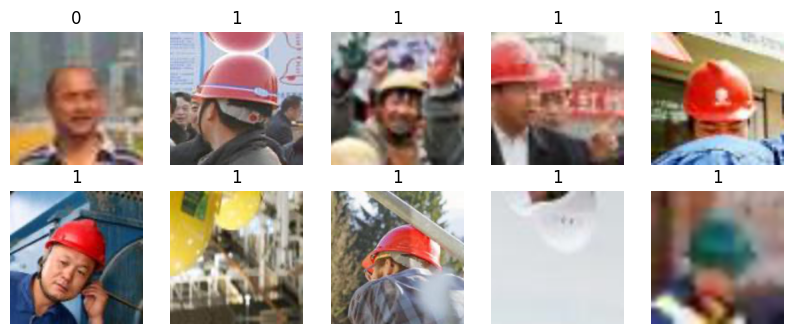

In [ ]:
import matplotlib.pyplot as plt
import random
plt.figure(figsize=(10,10))
for i in range(10):
  idx = random.randint(0, len(images)-1)
  plt.subplot(5,5,i+1)
  plt.imshow(images[idx])
  plt.title(labels[idx])
  plt.axis('off')
plt.show()

## Checking for class imbalance


Counter({np.int64(1): 3161, np.int64(0): 964})


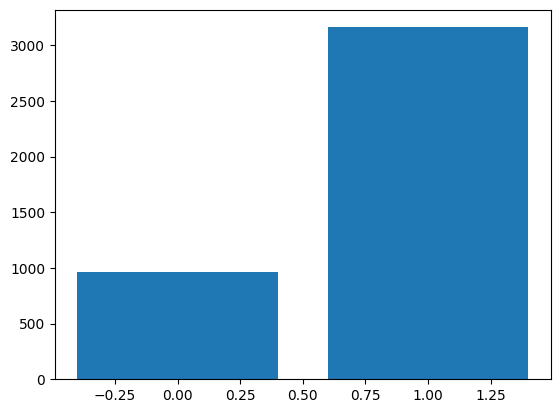

In [ ]:
from collections import Counter
counter = Counter(labels)
print(counter)
plt.bar(counter.keys(), counter.values())
plt.show()


# **Data Preprocessing**

### Data Normalization

In [ ]:

images = images.astype("float32") / 255.0


### Splitting the dataset



In [ ]:

X_train, X_temp, y_train, y_temp = train_test_split(
    images, labels,
    test_size=0.3,
    random_state=42,
    stratify=labels
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.5,
    random_state=42,
    stratify=y_temp
)

print(X_train.shape, X_val.shape, X_test.shape)

(2887, 200, 200, 3) (619, 200, 200, 3) (619, 200, 200, 3)


In [ ]:
 # Class Balance
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train),
    y=y_train
)

class_weights = dict(enumerate(class_weights))
print(class_weights)


{0: np.float64(2.1385185185185187), 1: np.float64(0.6525768535262206)}


# **Model Building**

##Model 1: Convolutional Neural Network (CNN) from Scratch

In [ ]:
# Model 1
cnn_model = models.Sequential([
    layers.Input(shape=(200,200,3)),

    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(len(np.unique(labels)), activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_cnn = cnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    class_weight=class_weights
)

print("CNN Test:")
cnn_model.evaluate(X_test, y_test)


Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 12s 34ms/step - accuracy: 0.6377 - loss: 0.6212 - val_accuracy: 0.6995 - val_loss: 0.5297
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7063 - loss: 0.5552 - val_accuracy: 0.7981 - val_loss: 0.4388
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.7478 - loss: 0.5289 - val_accuracy: 0.7771 - val_loss: 0.4818
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 28ms/step - accuracy: 0.7589 - loss: 0.5192 - val_accuracy: 0.7964 - val_loss: 0.4456
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.7686 - loss: 0.5066 - val_accuracy: 0.7997 - val_loss: 0.4338
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7690 - loss: 0.5092 - val_accuracy: 0.8013 - val_loss: 0.4359
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.7773 - loss: 0.5107 - val_accuracy: 0.7851 - val_loss: 0.4790
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 5s 25ms/step - accuracy: 0.7794 - loss: 0.5088 - val_acc

[0.48176896572113037, 0.8045234084129333]

##Model Evaluation Criterion

## Utility Functions

### Visualizing the predictions

## Model 2: Transfer Learning with VGG-16 (Base)

In [ ]:
# Convert photos to 224 so they work with VGG-16

In [ ]:
# Model 2
from tensorflow.keras.applications import VGG16
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(200,200,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.4)(x)

output = layers.Dense(len(np.unique(labels)), activation='softmax')(x)

vgg_model = tf.keras.Model(base_model.input, output)

vgg_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg = vgg_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    class_weight=class_weights
)

print("CNN Result:")
cnn_acc = cnn_model.evaluate(X_test, y_test)

print("VGG16 Result:")
vgg_acc = vgg_model.evaluate(X_test, y_test)


Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 16s 78ms/step - accuracy: 0.6630 - loss: 0.5853 - val_accuracy: 0.7884 - val_loss: 0.4597
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 13s 74ms/step - accuracy: 0.7392 - loss: 0.4878 - val_accuracy: 0.8110 - val_loss: 0.4181
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.7742 - loss: 0.4487 - val_accuracy: 0.8271 - val_loss: 0.3846
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 75ms/step - accuracy: 0.7915 - loss: 0.4184 - val_accuracy: 0.8271 - val_loss: 0.3652
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7852 - loss: 0.4098 - val_accuracy: 0.8336 - val_loss: 0.3652
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.8015 - loss: 0.3917 - val_accuracy: 0.8223 - val_loss: 0.3804
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 79ms/step - accuracy: 0.8105 - loss: 0.3839 - val_accuracy: 0.8368 - val_loss: 0.3590
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 15s 80ms/step - accuracy: 0.8188 - loss: 0.3730 - 

Using the the pretrained VGG16 the accuracy result was accuracy: accuracy: 0.9524 - loss: 0.1253 - val_accuracy: 0.9369 - val_loss: 0.2681

This model performed better than the CNN from scratch - accuracy: 0.9233 - loss: 0.1800 - val_accuracy: 0.9078 - val_loss: 0.2408

### Visualizing the predictions

## Model 3: Transfer Learning with VGG-16 (Base + FFNN)





In [ ]:

from tensorflow.keras.applications import VGG16

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(200,200,3)
)

base_model.trainable = False

x = layers.GlobalAveragePooling2D()(base_model.output)

x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

output = layers.Dense(len(np.unique(labels)), activation='softmax')(x)

vgg_ffnn_model = tf.keras.Model(base_model.input, output)

vgg_ffnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history_vgg_ffnn = vgg_ffnn_model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=16,
    class_weight=class_weights
)

vgg_ffnn_loss, vgg_ffnn_acc = vgg_ffnn_model.evaluate(X_test, y_test)

print("VGG16 (Base + FFNN) Accuracy:", vgg_ffnn_acc)


Epoch 1/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 17s 83ms/step - accuracy: 0.6304 - loss: 0.6169 - val_accuracy: 0.7948 - val_loss: 0.4499
Epoch 2/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 80ms/step - accuracy: 0.7357 - loss: 0.4966 - val_accuracy: 0.8078 - val_loss: 0.4048
Epoch 3/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.7683 - loss: 0.4556 - val_accuracy: 0.8223 - val_loss: 0.3786
Epoch 4/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7665 - loss: 0.4324 - val_accuracy: 0.8158 - val_loss: 0.3729
Epoch 5/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7839 - loss: 0.4204 - val_accuracy: 0.8158 - val_loss: 0.3558
Epoch 6/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 77ms/step - accuracy: 0.7963 - loss: 0.4075 - val_accuracy: 0.8158 - val_loss: 0.3946
Epoch 7/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.8064 - loss: 0.3921 - val_accuracy: 0.8288 - val_loss: 0.3409
Epoch 8/10
181/181 ━━━━━━━━━━━━━━━━━━━━ 14s 78ms/step - accuracy: 0.7988 - loss: 0.3919 - 

#### Visualizing the predictions

## Model 4: Transfer Learning with VGG-16 (Base + FFNN + Data Augmentation)

- In most of the real-world case studies, it is challenging to acquire a large number of images and then train CNNs.
- To overcome this problem, one approach we might consider is **Data Augmentation**.
- CNNs have the property of **translational invariance**, which means they can recognise an object even if its appearance shifts translationally in some way. - Taking this attribute into account, we can augment the images using the techniques listed below

    -  Horizontal Flip (should be set to True/False)
    -  Vertical Flip (should be set to True/False)
    -  Height Shift (should be between 0 and 1)
    -  Width Shift (should be between 0 and 1)
    -  Rotation (should be between 0 and 180)
    -  Shear (should be between 0 and 1)
    -  Zoom (should be between 0 and 1) etc.

Remember, **data augmentation should not be used in the validation/test data set**.

In [ ]:
# Model 4

from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np

train_datagen = ImageDataGenerator(
  rotation_range = 20,
  width_shift_range = 0.1,
  height_shift_range = 0.1,
  zoom_range = 0.2,
  shear_range = 0.15,
  horizontal_flip = True,
  vertical_flip = True
)

val_datagen = ImageDataGenerator()

train_generator = train_datagen.flow(
    X_train,
    y_train,
    batch_size=8,
    shuffle=True
)

val_generator = val_datagen.flow(
    X_val,
    y_val,
    batch_size=8,
    shuffle=False
)

base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

base_model.trainable = False


inputs = tf.keras.Input(shape=(200, 200, 3))


x = layers.Resizing(224, 224)(inputs)


x = base_model(x)


x = layers.GlobalAveragePooling2D()(x)

x = layers.Dense(512, activation='relu')(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(256, activation='relu')(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(len(np.unique(y_train)), activation='softmax')(x)


model = tf.keras.Model(inputs, outputs)


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    class_weight=class_weights
)

model.evaluate(X_test, y_test)



Epoch 1/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 55s 140ms/step - accuracy: 0.6702 - loss: 0.7569 - val_accuracy: 0.7674 - val_loss: 0.4904
Epoch 2/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 50s 137ms/step - accuracy: 0.7146 - loss: 0.5839 - val_accuracy: 0.7415 - val_loss: 0.5262
Epoch 3/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 50s 139ms/step - accuracy: 0.7361 - loss: 0.5097 - val_accuracy: 0.7964 - val_loss: 0.4366
Epoch 4/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 49s 135ms/step - accuracy: 0.7430 - loss: 0.5171 - val_accuracy: 0.8158 - val_loss: 0.3920
Epoch 5/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 50s 137ms/step - accuracy: 0.7541 - loss: 0.4865 - val_accuracy: 0.7835 - val_loss: 0.4777
Epoch 6/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 48s 134ms/step - accuracy: 0.7572 - loss: 0.4756 - val_accuracy: 0.8384 - val_loss: 0.3581
Epoch 7/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 48s 133ms/step - accuracy: 0.7624 - loss: 0.4697 - val_accuracy: 0.8158 - val_loss: 0.3926
Epoch 8/10
361/361 ━━━━━━━━━━━━━━━━━━━━ 48s 132ms/step - accuracy: 0.7610 - loss: 0

[0.40730491280555725, 0.7867528200149536]

#### Visualizing the predictions

# **Model Performance Comparison and Final Model Selection**

## Test Performance

# **Actionable Insights & Recommendations**

-
-

<font size=5 color='blue'>Power Ahead!</font>
___